# Optimization Log Copilot

EN.705.605.81.SP26 Introduction to Generative AI

Jeff Ginn

---

This notebook implements the Optimization Log Copilot pipeline for analyzing
mathematical optimization solver logs. The pipeline parses 188 solver runs
into structured features, applies heuristic rules to detect five common
performance bottlenecks (weak root LP, excessive branching, ineffective cuts,
degeneracy, presolve weakness), trains a PyTorch multi-label classifier on
those weak labels with held-out validation, and uses retrieval-augmented
generation with `SentenceTransformer` and `Llama-3.2-1B-Instruct` to produce
natural-language diagnostics. A 30-run hand-reviewed gold subset provides
independent ground truth for evaluating both the heuristic rules and the
trained classifier. The notebook uses the same PyTorch / HuggingFace stack
covered in our course assignments (Modules 6-12).


## 1. Imports and Setup

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
plt.rcParams['axes.grid'] = True

import numpy as np
import os
import sys
import re
import json
import warnings
from dataclasses import dataclass, asdict``

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.simplefilter('ignore', category=FutureWarning)
warnings.simplefilter('ignore', category=UserWarning)

print(f'PyTorch version= {torch.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

Device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {Device}')

# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


PyTorch version= 2.10.0
CUDA available= False
Using device: cpu


## 2. Load the Dataset

`rose_logs_parsed_v2_slim.csv` is produced by `parse_rose_logs_v2.py` and
contains 188 solver runs:

- 90 MIPLIB problems run under the `branching_heavy` configuration
- the same 90 MIPLIB problems run under the `heuristic_heavy` configuration
- 8 Ramsey-type problems (tagged `ramsey`)

The two MIPLIB configurations are different builds of the Rose solver with internal
heuristic-policy changes between the two builds.

- **`branching_heavy`** corresponds to Rose 5.23.1-develop-4-g160c19936
  (staging branch, April 9 build). Across the 90 paired problems it
  explored 44% more branch-and-bound nodes per problem at the median.
- **`heuristic_heavy`** corresponds to Rose 5.23.1-release (April 14 build).
  It found 13% more incumbents per run on the same problems and was slightly
  faster overall.

Identifying columns are `run_id`, `config_name`, `problem_name`, `run_name`.
The slim CSV omits the full `stdout_clean` text, which includes the detailed log statements, so that everything fits comfortably in memory for the classifier.


In [156]:
DATA_PATH = 'rose_logs_parsed_v2_slim.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Loaded {len(df_raw)} solver runs x {df_raw.shape[1]} columns')
print(f'\nConfigurations:')
print(df_raw['config_name'].value_counts().to_string())
print(f'\nUnique problems: {df_raw["problem_name"].nunique()}')

# pairing: same problem under multiple configs
paired = df_raw.groupby('problem_name')['config_name'].nunique()
print(f'Problems with paired runs (>=2 configs): {(paired >= 2).sum()}')

df_raw[['run_id', 'config_name', 'problem_name',
        'status_solution_status', 'status_termination_reason',
        'metric_timeline_total_seconds',
        'metric_num_nodes_total',
        'problem_num_constraints', 'problem_num_variables',
        'derived_is_optimal', 'derived_timed_out']].head(10)


Loaded 188 solver runs x 234 columns

Configurations:
config_name
branching_heavy    90
heuristic_heavy    90
ramsey              8

Unique problems: 98
Problems with paired runs (>=2 configs): 90


,run_id,config_name,problem_name,status_solution_status,status_termination_reason,metric_timeline_total_seconds,metric_num_nodes_total,problem_num_constraints,problem_num_variables,derived_is_optimal,derived_timed_out
0,branching_heavy::30n20b8,branching_heavy,30n20b8,feasible,timeout,3600.899741,1920018,576,18380,0,1
1,branching_heavy::50v-10,branching_heavy,50v-10,feasible,timeout,3600.016867,4325446,233,2013,0,1
2,branching_heavy::air05,branching_heavy,air05,optimal,finished,11.650280,481,426,7195,1,0
3,branching_heavy::app1-1,branching_heavy,app1-1,optimal,finished,5.552544,16077,4926,2480,1,0
4,branching_heavy::app1-2,branching_heavy,app1-2,optimal,finished,485.785341,116495,53467,26871,1,0
5,branching_heavy::binkar10_1,branching_heavy,binkar10_1,optimal,finished,511.130101,9575303,1026,2298,1,0
6,branching_heavy::bppc8-02,branching_heavy,bppc8-02,optimal,finished,1.336860,8699,59,232,1,0
7,branching_heavy::cheese,branching_heavy,cheese,optimal,finished,1.348972,2593,130,165,1,0
8,branching_heavy::dano3_3,branching_heavy,dano3_3,optimal,finished,58.083067,20,3202,13873,1,0
9,branching_heavy::dano3_5,branching_heavy,dano3_5,optimal,finished,56.945466,717,3202,13873,1,0


## 3. Solver Log Feature Object

A `SolverLogFeatures` dataclass captures the per-run state used by every
downstream component: identifying columns, problem dimensions, solution
status, timing, tree-search statistics, cut counts, bound trajectory, and
several derived ratios.


In [157]:
@dataclass
class SolverLogFeatures:
    # identity
    run_id: str
    config_name: str
    problem_name: str
    # problem dimensions
    num_constraints: int = 0
    num_variables: int = 0
    num_nonzeros: int = 0
    num_presolved_constraints: int = 0
    num_presolved_variables: int = 0
    # solution status
    solution_status: str = ''
    termination_reason: str = ''
    objective: float | None = None
    # timing
    total_time_sec: float = 0.0
    solve_time_sec: float = 0.0
    presolve_time_sec: float = 0.0
    # tree search
    num_nodes_total: int = 0
    num_nodes_processed: int = 0
    num_nodes_pruned: int = 0
    num_lp_iterations: int = 0
    num_solutions_found: int = 0
    # cuts
    num_cuts_generated: int = 0
    num_cuts_applied: int = 0
    # bounds
    first_dual: float | None = None
    final_dual: float | None = None
    final_primal: float | None = None
    final_rel_gap: float | None = None
    bounds_num_updates: int = 0
    # stages
    stages_observed: str = ''
    # derived
    presolve_var_reduction: float | None = None
    presolve_con_reduction: float | None = None
    cut_efficiency: float | None = None
    nodes_per_second: float | None = None
    lp_iter_per_var: float | None = None
    is_optimal: int = 0
    has_solution: int = 0
    timed_out: int = 0
    solved_in_presolve: int = 0


def row_to_features(row):
    # helper function for missing or NaN values
    def safe(col, default=0):
        v = row.get(col, default)
        if isinstance(v, float) and pd.isna(v):
            return default
        if v is None:
            return default
        return v

    return SolverLogFeatures(
        run_id=str(row['run_id']),
        config_name=str(row['config_name']),
        problem_name=str(row['problem_name']),
        num_constraints=int(safe('problem_num_constraints')),
        num_variables=int(safe('problem_num_variables')),
        num_nonzeros=int(safe('problem_num_nonzeros')),
        num_presolved_constraints=int(safe('problem_num_presolved_constraints')),
        num_presolved_variables=int(safe('problem_num_presolved_variables')),
        solution_status=str(safe('status_solution_status', '')),
        termination_reason=str(safe('status_termination_reason', '')),
        objective=row.get('status_objective') if pd.notna(row.get('status_objective')) else None,
        total_time_sec=float(safe('metric_timeline_total_seconds', 0.0)),
        solve_time_sec=float(safe('metric_timeline_solve_seconds', 0.0)),
        presolve_time_sec=float(safe('metric_timeline_presolve_seconds', 0.0)),
        num_nodes_total=int(safe('metric_num_nodes_total')),
        num_nodes_processed=int(safe('metric_num_nodes_processed')),
        num_nodes_pruned=int(safe('metric_num_nodes_pruned')),
        num_lp_iterations=int(safe('metric_num_lp_iterations')),
        num_solutions_found=int(safe('metric_num_solutions_found')),
        num_cuts_generated=int(safe('metric_num_cuts_generated')),
        num_cuts_applied=int(safe('metric_num_cuts_applied')),
        first_dual=row.get('bounds_first_dual') if pd.notna(row.get('bounds_first_dual')) else None,
        final_dual=row.get('bounds_final_dual') if pd.notna(row.get('bounds_final_dual')) else None,
        final_primal=row.get('bounds_final_primal') if pd.notna(row.get('bounds_final_primal')) else None,
        final_rel_gap=row.get('bounds_final_rel_gap') if pd.notna(row.get('bounds_final_rel_gap')) else None,
        bounds_num_updates=int(safe('bounds_num_updates')),
        stages_observed=str(safe('stages_observed', '')),
        presolve_var_reduction=row.get('derived_presolve_var_reduction') if pd.notna(row.get('derived_presolve_var_reduction')) else None,
        presolve_con_reduction=row.get('derived_presolve_con_reduction') if pd.notna(row.get('derived_presolve_con_reduction')) else None,
        cut_efficiency=row.get('derived_cut_efficiency') if pd.notna(row.get('derived_cut_efficiency')) else None,
        nodes_per_second=row.get('derived_nodes_per_second') if pd.notna(row.get('derived_nodes_per_second')) else None,
        lp_iter_per_var=row.get('derived_lp_iter_per_var') if pd.notna(row.get('derived_lp_iter_per_var')) else None,
        is_optimal=int(safe('derived_is_optimal')),
        has_solution=int(safe('derived_has_solution')),
        timed_out=int(safe('derived_timed_out')),
        solved_in_presolve=int(safe('solved_in_presolve')),
    )


parsed_logs = [row_to_features(r) for _, r in df_raw.iterrows()]
print(f'Parsed {len(parsed_logs)} solver run feature objects.')

# sanity check
for pl in parsed_logs[:3]:
    print(f'\n  {pl.run_id}')
    print(f'    status={pl.solution_status:>10s}  term={pl.termination_reason:>10s}  '
          f'nodes={pl.num_nodes_total:>10,}  '
          f'cuts_gen={pl.num_cuts_generated:>5}  '
          f'gap={pl.final_rel_gap}')


Parsed 188 solver run feature objects.

  branching_heavy::30n20b8
    status=  feasible  term=   timeout  nodes= 1,920,018  cuts_gen= 2936  gap=0.763484751626698

  branching_heavy::50v-10
    status=  feasible  term=   timeout  nodes= 4,325,446  cuts_gen= 1980  gap=0.103596497707819

  branching_heavy::air05
    status=   optimal  term=  finished  nodes=       481  cuts_gen= 3672  gap=0.0


## 4. Heuristic Bottleneck Labels

The thresholds below are chosen against the empirical distribution of the
188-run dataset. Each rule combines a primary signal with a guard condition
so that "easy" cases (problems solved entirely in presolve, tiny problems,
etc.) do not trigger spurious labels.

| Label                | Primary signal                             | Guard                          |
|----------------------|--------------------------------------------|--------------------------------|
| weak_root_lp         | final relative gap >= 5%                   | OR no solution and not solved in presolve |
| excessive_branching  | nodes per variable >= 100                  | AND nodes >= 1000              |
| ineffective_cuts     | >= 100 cuts generated, dual moved < 1%     | AND not solved in presolve     |
| degeneracy           | LP iterations per variable >= 1.0          | AND num_variables >= 10        |
| presolve_weakness    | < 1% reduction in vars *and* constraints   | AND not solved in presolve     |

These rules are heuristic and noisy. They serve as the **weak supervision**
signal for the PyTorch classifier in Section 7 and as the **anchor labels**
passed to the LLM in Section 9. Section 12 evaluates them against a
hand-reviewed gold subset to characterize their precision and recall.


In [158]:
BOTTLENECK_LABELS = [
    'weak_root_lp',
    'excessive_branching',
    'ineffective_cuts',
    'degeneracy',
    'presolve_weakness',
]
K = len(BOTTLENECK_LABELS)

# --- Heuristic-rule thresholds ---
# Each rule combines a primary signal with a guard so that easy cases
# (problems solved entirely in presolve, tiny problems) do not trigger
# spurious labels.

# weak_root_lp: solver finished with a non-trivial optimality gap
WEAK_ROOT_LP_GAP_THRESHOLD = 0.05            # final relative gap >= 5%

# excessive_branching: many B&B nodes relative to problem size
EXCESSIVE_BRANCHING_NODES_PER_VAR = 100      # nodes / variables >= 100
EXCESSIVE_BRANCHING_MIN_NODES = 1000         # AND absolute node count >= 1000

# ineffective_cuts: many cuts generated but the dual barely moved
INEFFECTIVE_CUTS_MIN_GENERATED = 100         # >= 100 cuts generated
INEFFECTIVE_CUTS_DUAL_MOVE_THRESHOLD = 0.01  # AND dual bound moved < 1%

# degeneracy: high LP-iteration-per-variable ratio on a non-trivial problem
DEGENERACY_LP_ITER_PER_VAR = 1.0             # LP iterations / variables >= 1.0
DEGENERACY_MIN_VARS = 10                     # AND problem has >= 10 variables

# presolve_weakness: presolve made essentially no reduction in the model
PRESOLVE_WEAKNESS_VAR_REDUCTION = 0.01       # < 1% variable reduction
PRESOLVE_WEAKNESS_CON_REDUCTION = 0.01       # AND < 1% constraint reduction


def label_log(f):
    labels = np.zeros(K, dtype=np.float32)

    # Helper: dual bound improvement from root LP to final, normalized by
    # max(|first_dual|, 1.0) to avoid amplifying near-zero starting bounds.
    if f.first_dual is not None and f.final_dual is not None:
        dual_imp = abs(f.final_dual - f.first_dual) / max(abs(f.first_dual), 1.0)
    else:
        dual_imp = 0.0

    nodes_per_var = f.num_nodes_total / f.num_variables if f.num_variables > 0 else 0.0

    # 1. Weak root LP / unable to close gap
    if (f.final_rel_gap is not None and f.final_rel_gap >= WEAK_ROOT_LP_GAP_THRESHOLD) or (
        f.has_solution == 0 and f.solved_in_presolve == 0
    ):
        labels[0] = 1.0

    # 2. Excessive branching
    if (nodes_per_var >= EXCESSIVE_BRANCHING_NODES_PER_VAR
            and f.num_nodes_total >= EXCESSIVE_BRANCHING_MIN_NODES):
        labels[1] = 1.0

    # 3. Ineffective cuts
    if (f.num_cuts_generated >= INEFFECTIVE_CUTS_MIN_GENERATED
            and dual_imp < INEFFECTIVE_CUTS_DUAL_MOVE_THRESHOLD
            and f.solved_in_presolve == 0):
        labels[2] = 1.0

    # 4. Degeneracy
    if (f.lp_iter_per_var is not None
            and f.lp_iter_per_var >= DEGENERACY_LP_ITER_PER_VAR
            and f.num_variables >= DEGENERACY_MIN_VARS):
        labels[3] = 1.0

    # 5. Presolve weakness
    if (f.presolve_var_reduction is not None
            and f.presolve_var_reduction < PRESOLVE_WEAKNESS_VAR_REDUCTION
            and f.presolve_con_reduction is not None
            and f.presolve_con_reduction < PRESOLVE_WEAKNESS_CON_REDUCTION
            and f.solved_in_presolve == 0):
        labels[4] = 1.0

    return labels


label_matrix = np.array([label_log(f) for f in parsed_logs])
label_df = pd.DataFrame(label_matrix, columns=BOTTLENECK_LABELS,
                        index=[f.run_id for f in parsed_logs])

print('Per-label prevalence (fraction of runs with each label set):')
for c in BOTTLENECK_LABELS:
    p = label_df[c].mean()
    n = int(label_df[c].sum())
    print(f'  {c:22s} : {p:>5.1%}  ({n}/{len(label_df)})')

# Cardinality: how many of the 5 labels fire per run?
labels_per_run = label_df.sum(axis=1)
print(f'\nLabel cardinality (number of bottlenecks per run):')
print(f'  runs flagged with >=1 bottleneck   : {(labels_per_run >= 1).mean():.1%}')
print(f'  runs flagged with >=2 bottlenecks  : {(labels_per_run >= 2).mean():.1%}')
print(f'  mean number of bottlenecks per run : {labels_per_run.mean():.2f}')


Per-label prevalence (fraction of runs with each label set):
  weak_root_lp           : 13.8%  (26/188)
  excessive_branching    : 29.3%  (55/188)
  ineffective_cuts       : 22.9%  (43/188)
  degeneracy             :  8.5%  (16/188)
  presolve_weakness      : 20.2%  (38/188)

Label cardinality (number of bottlenecks per run):
  runs flagged with >=1 bottleneck   : 63.8%
  runs flagged with >=2 bottlenecks  : 24.5%
  mean number of bottlenecks per run : 0.95


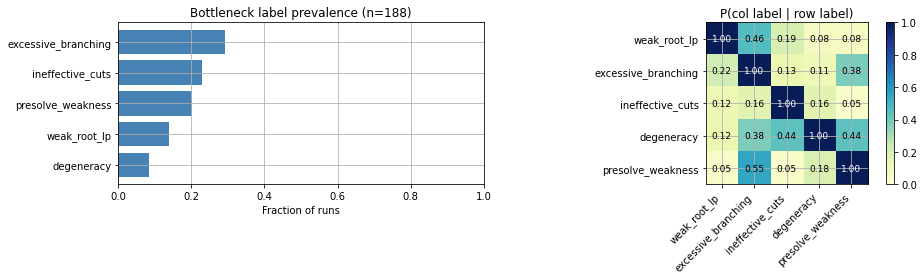

In [159]:
# Visualize label prevalence and co-occurrence
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

prevalence = label_df.mean().sort_values(ascending=True)
axes[0].barh(prevalence.index, prevalence.values, color='steelblue')
axes[0].set_xlabel('Fraction of runs')
axes[0].set_title('Bottleneck label prevalence (n=188)')
axes[0].set_xlim(0, 1)

# co-occurrence heatmap
co = label_df.T @ label_df  # K x K matrix of joint counts
co_norm = co / np.diag(co)[:, None].clip(min=1)  # P(col | row)
im = axes[1].imshow(co_norm.values, cmap='YlGnBu', vmin=0, vmax=1)
axes[1].set_xticks(range(K))
axes[1].set_yticks(range(K))
axes[1].set_xticklabels(BOTTLENECK_LABELS, rotation=45, ha='right')
axes[1].set_yticklabels(BOTTLENECK_LABELS)
axes[1].set_title('P(col label | row label)')
for i in range(K):
    for j in range(K):
        axes[1].text(j, i, f'{co_norm.values[i,j]:.2f}',
                     ha='center', va='center',
                     color='black' if co_norm.values[i,j] < 0.6 else 'white',
                     fontsize=9)
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


## 5. Feature Engineering

Build a numerical feature matrix from the parsed feature objects. Many features are heavy-tailed (node counts span 0 to 100M+), so we `log1p`-transform the count columns before scaling.


In [160]:
COUNT_FEATURES = [
    'num_constraints', 'num_variables', 'num_nonzeros',
    'num_presolved_constraints', 'num_presolved_variables',
    'num_nodes_total', 'num_nodes_processed', 'num_nodes_pruned',
    'num_lp_iterations', 'num_solutions_found',
    'num_cuts_generated', 'num_cuts_applied',
]
RATIO_FEATURES = [
    'total_time_sec', 'solve_time_sec', 'presolve_time_sec',
    'presolve_var_reduction', 'presolve_con_reduction',
    'cut_efficiency', 'nodes_per_second', 'lp_iter_per_var',
    'final_rel_gap',
]
BINARY_FEATURES = [
    'is_optimal', 'has_solution', 'timed_out', 'solved_in_presolve',
]
FEATURE_COLS = COUNT_FEATURES + RATIO_FEATURES + BINARY_FEATURES
N_FEATURES = len(FEATURE_COLS)
print(f'Total features: {N_FEATURES}')


def features_to_array(parsed_logs):
    rows = []
    for f in parsed_logs:
        d = asdict(f)
        # log1p the counts
        row = []
        for c in COUNT_FEATURES:
            row.append(np.log1p(float(d.get(c) or 0)))
        for c in RATIO_FEATURES:
            v = d.get(c)
            row.append(float(v) if v is not None else 0.0)
        for c in BINARY_FEATURES:
            row.append(float(d.get(c) or 0))
        rows.append(row)
    return np.asarray(rows, dtype=np.float32)


X_full = features_to_array(parsed_logs)
y_full = label_matrix

print(f'X shape: {X_full.shape}, y shape: {y_full.shape}')
print(f'X stats: min={X_full.min():.2f}  max={X_full.max():.2f}  '
      f'mean={X_full.mean():.2f}  std={X_full.std():.2f}')


Total features: 25
X shape: (188, 25), y shape: (188, 5)
X stats: min=0.00  max=351526.34  mean=674.08  std=9873.31


## 6. Train / Validation Split + PyTorch Dataset

Hold out 25% of runs as a validation set using `sklearn.model_selection.train_test_split`
with a fixed random seed. Standard scaling is fit on the training split only
and applied to both splits. Training and validation sets are wrapped in a
PyTorch `Dataset` subclass that pre-converts the feature and label arrays
to `torch.float32` tensors.


In [161]:
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_full, y_full, np.arange(len(parsed_logs)),
    test_size=0.25, random_state=SEED,
)
print(f'Train: {len(X_train)}   Val: {len(X_val)}')

# Fit scaler on training data only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)


# PyTorch Dataset
class SolverLogDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_ds = SolverLogDataset(X_train_s, y_train)
val_ds = SolverLogDataset(X_val_s, y_val)

# Each training sample's weight is the average inverse-frequency of the
# positive labels it carries; samples with no positive labels get weight 1.
class_freq = y_train.mean(axis=0)
class_weight = 1.0 / np.maximum(class_freq, 1e-6)
sample_weights = []
for y_row in y_train:
    pos = np.where(y_row > 0)[0]
    sample_weights.append(class_weight[pos].mean() if len(pos) > 0 else 1.0)
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)
sampler = WeightedRandomSampler(
    sample_weights_t, num_samples=len(train_ds), replacement=True,
)

train_dl = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)

xb, yb = next(iter(train_dl))
print(f'Batch X: {tuple(xb.shape)}   Batch y: {tuple(yb.shape)}')


Train: 141   Val: 47
Batch X: (16, 25)   Batch y: (16, 5)


## 7. PyTorch Bottleneck Classifier

A small feed-forward network with two hidden layers of 64 units, ReLU
activations, dropout (rate 0.3), and a five-output sigmoid head producing
one probability per bottleneck label (from Module 9).

Training uses `BCELoss` over the sigmoid outputs and the AdamW optimizer
with weight decay $10^{-4}$. To address multi-label class imbalance, the
training `DataLoader` uses a `WeightedRandomSampler` (Module 6)
where each sample's weight is the average inverse class frequency of its
positive labels; samples with no positive labels get weight 1.


In [162]:
class BottleneckClassifier(nn.Module):

    def __init__(self, n_input, n_hidden, n_output, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(n_hidden, n_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # returns probabilities (sigmoid is in the final layer)
        return self.net(x)


N_HIDDEN = 64
EPOCHS_CLS = 300
LR_CLS = 1e-3
WEIGHT_DECAY = 1e-4

model_cls = BottleneckClassifier(N_FEATURES, N_HIDDEN, K).to(Device)


def params_count(net):
    return sum(p.numel() for p in net.parameters() if p.requires_grad)


print(model_cls)
print(f'\nNum params: {params_count(model_cls):,}')


BottleneckClassifier(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
    (7): Sigmoid()
  )
)

Num params: 6,149


### Training

In [163]:
%%time

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model_cls.parameters(), lr=LR_CLS, weight_decay=WEIGHT_DECAY)

train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS_CLS):
    # train
    model_cls.train()
    train_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(Device), yb.to(Device)
        optimizer.zero_grad()
        probs = model_cls(xb)
        loss = criterion(probs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)
    train_loss_history.append(train_loss)

    # val
    model_cls.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(Device), yb.to(Device)
            probs = model_cls(xb)
            loss = criterion(probs, yb)
            val_loss += loss.item() * len(xb)
    val_loss /= len(val_ds)
    val_loss_history.append(val_loss)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        sys.stderr.write(
            f'\rEpoch {epoch+1:3d}/{EPOCHS_CLS} | train={train_loss:.4f} val={val_loss:.4f}'
        )
        sys.stderr.flush()

print(f'\nFinal train loss: {train_loss_history[-1]:.4f}')
print(f'Final val   loss: {val_loss_history[-1]:.4f}')


Epoch 300/300 | train=0.0388 val=0.3102


Final train loss: 0.0388
Final val   loss: 0.3102
CPU times: user 1.78 s, sys: 269 ms, total: 2.04 s
Wall time: 2.03 s


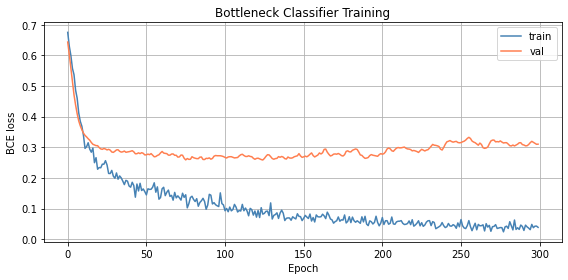

In [164]:
# Loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_loss_history, label='train', color='steelblue')
ax.plot(val_loss_history, label='val', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE loss')
ax.set_title('Bottleneck Classifier Training')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Evaluation: Per-Label Metrics

Per-label precision, recall, F1, ROC-AUC, and average precision are
computed on the 47-run validation split. ROC-AUC and average precision use
the predicted probability scores; precision, recall, and F1 use the binary
predictions thresholded at 0.5. Macro and micro F1 summaries are reported
alongside subset accuracy (the fraction of validation runs with all five
labels predicted exactly correctly).


In [165]:
THRESHOLD = 0.5

model_cls.eval()
with torch.no_grad():
    val_probs = model_cls(
        torch.tensor(X_val_s, dtype=torch.float32).to(Device)
    ).cpu().numpy()
val_preds = (val_probs >= THRESHOLD).astype(int)

# per-label metrics
metrics = []
for i, name in enumerate(BOTTLENECK_LABELS):
    y_true = y_val[:, i].astype(int)
    y_pred = val_preds[:, i]
    y_prob = val_probs[:, i]
    n_pos = int(y_true.sum())
    if n_pos == 0 or n_pos == len(y_true):
        # ROC-AUC is undefined for single-class subsets
        auc = float('nan')
        ap = float('nan')
    else:
        auc = roc_auc_score(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    metrics.append({
        'label': name, 'support_pos': n_pos,
        'precision': p, 'recall': r, 'f1': f1,
        'roc_auc': auc, 'avg_prec': ap,
    })

metrics_df = pd.DataFrame(metrics).set_index('label')
print('Validation set per-label metrics:')
print(metrics_df.round(3).to_string())

print(f'\nMacro-F1:    {metrics_df["f1"].mean():.3f}')
print(f'Micro-F1:    {f1_score(y_val.astype(int), val_preds, average="micro", zero_division=0):.3f}')
print(f'Subset acc:  {(val_preds == y_val.astype(int)).all(axis=1).mean():.3f}')


Validation set per-label metrics:
                     support_pos  precision  recall     f1  roc_auc  avg_prec
label                                                                        
weak_root_lp                   4      1.000   1.000  1.000    1.000     1.000
excessive_branching           13      0.857   0.923  0.889    0.977     0.946
ineffective_cuts              13      0.846   0.846  0.846    0.943     0.899
degeneracy                     7      1.000   0.714  0.833    0.836     0.777
presolve_weakness             10      0.800   0.800  0.800    0.943     0.834

Macro-F1:    0.874
Micro-F1:    0.860
Subset acc:  0.766


## 9. RAG-Based Diagnostic Generation

This section implements the **R**etrieval-**A**ugmented **G**eneration approach
covered in Module 12:

1. **Knowledge base** - 12 short "bottleneck pattern" documents that describe
   each failure mode plus typical solver-configuration recommendations.
2. **Retrieval** - encode each KB document with `SentenceTransformer
   ('all-MiniLM-L6-v2')`. For a given log, build a structured query string
   from its parsed metrics and retrieve KB entries by cosine similarity.
   Retrieval is conditioned on the heuristic-detected labels (or
   `healthy_solve` when no labels fire) so the context the LLM sees is
   topically aligned with what the rules found.
3. **Generation** - prompt `meta-llama/Llama-3.2-1B-Instruct` (the same
   instruction-tuned model used in the Module 12 assignment) via its chat
   template, with a focused system instruction plus a single user turn
   containing the run summary, the detected bottleneck labels, and the
   top-2 retrieved knowledge-base entries. The system instruction allows
   "no bottleneck" as a valid output so healthy runs are not forced into
   a bottleneck diagnosis.


In [166]:
# Knowledge base: short curated documents tying each bottleneck label
# to its observable signature in solver metrics and the standard
# remediation. These are the "context" the RAG component will retrieve.

KB = [
    {'topic': 'weak_root_lp',
     'context': 'A weak root LP relaxation is indicated by a large optimality gap remaining at solver termination, often combined with a timeout. The LP bound is far from the integer optimum, so branch-and-bound cannot prove optimality. Recommended actions: strengthen the formulation with valid inequalities, enable more aggressive cut generation (cut_aggressiveness=2 or 3), increase presolve passes, or supply a tighter big-M.'},
    {'topic': 'weak_root_lp',
     'context': 'When the solver terminates with status no_solution and was not solved in presolve, the relaxation provided no feasibility-preserving information. This may indicate an infeasible model, a poor formulation, or insufficient time. Recommended actions: increase the time limit, run an IIS analysis to detect infeasibility, or reformulate constraints that may be redundant or contradictory.'},
    {'topic': 'excessive_branching',
     'context': 'Excessive branching is signalled by a node count that is large relative to the number of variables (nodes_per_var > 100). The branch-and-bound tree is exploding because variable selection is poor, the LP relaxation is loose, or the problem has symmetry. Recommended actions: enable strong branching, use pseudocost branching, add symmetry-breaking constraints, or increase cut aggressiveness to tighten the relaxation before branching.'},
    {'topic': 'excessive_branching',
     'context': 'A high node count combined with low cut effectiveness suggests the LP bound is not improving fast enough between branches. Try enabling Gomory and MIR cuts at every node, increasing cut depth, or using diving heuristics earlier to find feasible solutions and prune the tree.'},
    {'topic': 'ineffective_cuts',
     'context': 'When many cuts are generated but the dual bound barely changes (less than 1% improvement from root LP to final), the cut pool is producing redundant or shallow cuts. Recommended actions: switch from cover cuts to MIR or strong-CG cuts, limit cut rounds to avoid LP slowdown, or apply cut filtering by orthogonality and efficacy thresholds.'},
    {'topic': 'ineffective_cuts',
     'context': 'Ineffective cutting plane behaviour often co-occurs with weak root LP and excessive branching. The remediation is the same: strengthen the formulation upstream, since cuts cannot fix a fundamentally loose relaxation.'},
    {'topic': 'degeneracy',
     'context': 'High LP iterations per variable (greater than 1.0) usually indicates degeneracy in the simplex method. Repeated pivoting on alternative optima slows down every node solve. Recommended actions: switch from primal to dual simplex, enable perturbation, use barrier or interior-point methods for the root LP, or apply Bland\'s rule to guarantee termination.'},
    {'topic': 'degeneracy',
     'context': 'Degenerate LPs can also be caused by high-dimensional polytopes with many faces of optimal solutions. Reducing redundant constraints in presolve and tightening variable bounds often helps the simplex method reach a vertex faster.'},
    {'topic': 'presolve_weakness',
     'context': 'Presolve weakness shows up as little or no reduction in the number of variables or constraints (less than 1% reduction). This means the formulation contains few exploitable structures - no fixings, no aggregations, no dominated constraints. Recommended actions: tighten variable bounds, eliminate dominated rows manually, normalize coefficient magnitudes, and pre-aggregate equivalent variables before passing the model to the solver.'},
    {'topic': 'presolve_weakness',
     'context': 'When presolve is weak, downstream stages (cuts and branching) carry the entire burden of solving the model. Strengthening presolve via custom preprocessing, or by enabling additional presolve passes if the solver supports it, often yields the largest single speedup.'},
    {'topic': 'healthy_solve',
     'context': 'A healthy solver run terminates with status optimal, a small node count relative to problem size, presolve reductions of 10% or more, and a final relative gap of zero. No diagnostic action is required when the run already shows healthy behaviour.'},
    {'topic': 'healthy_solve',
     'context': 'When a problem is solved entirely in presolve (solved_in_presolve=1), the formulation is so tight that no branch-and-bound is required. This is the desired outcome and indicates that the model has been formulated effectively for this solver.'},
]

KB_df = pd.DataFrame(KB)
print(f'Knowledge base: {len(KB_df)} documents covering {KB_df["topic"].nunique()} bottleneck patterns')
print(KB_df['topic'].value_counts().to_string())


Knowledge base: 12 documents covering 6 bottleneck patterns
topic
weak_root_lp           2
excessive_branching    2
ineffective_cuts       2
degeneracy             2
presolve_weakness      2
healthy_solve          2


In [167]:
def render_log_summary(f):
    '''Render a SolverLogFeatures object as a compact structured summary
    suitable for use as both an embedding query and an LLM prompt input.'''
    lines = [
        f'Problem: {f.problem_name}  (configuration: {f.config_name})',
        f'Size: {f.num_variables:,} variables, {f.num_constraints:,} constraints, {f.num_nonzeros:,} nonzeros.',
        f'Termination: status={f.solution_status}, reason={f.termination_reason}.',
        f'Total time: {f.total_time_sec:.1f} s   (presolve {f.presolve_time_sec:.1f} s, solve {f.solve_time_sec:.1f} s).',
        f'Tree: {f.num_nodes_total:,} nodes total, {f.num_lp_iterations:,} LP iterations, {f.num_solutions_found} solutions found.',
        f'Cuts: {f.num_cuts_generated} generated / {f.num_cuts_applied} applied.',
    ]
    if f.num_variables > 0:
        lines.append(f'Presolve reduction: {(f.presolve_var_reduction or 0):.1%} of variables, {(f.presolve_con_reduction or 0):.1%} of constraints.')
    if f.first_dual is not None and f.final_dual is not None:
        lines.append(f'Dual bound: {f.first_dual:.4g} (root) -> {f.final_dual:.4g} (final).')
    if f.final_rel_gap is not None:
        lines.append(f'Final relative gap: {f.final_rel_gap:.2%}.')
    return '\n'.join(lines)


# pretty-print one example log summary
print(render_log_summary(parsed_logs[0]))


Problem: 30n20b8  (configuration: branching_heavy)
Size: 18,380 variables, 576 constraints, 109,706 nonzeros.
Termination: status=feasible, reason=timeout.
Total time: 3600.9 s   (presolve 3.0 s, solve 3597.8 s).
Tree: 1,920,018 nodes total, 537 LP iterations, 657 solutions found.
Cuts: 2936 generated / 0 applied.
Presolve reduction: 74.2% of variables, 15.5% of constraints.
Dual bound: 122.8 (root) -> 154.4 (final).
Final relative gap: 76.35%.


In [168]:
# Build the embedding index over the knowledge base.
# We use the same SentenceTransformer model the user used in Assignment 12.
from sentence_transformers import SentenceTransformer

EMBEDDER = SentenceTransformer('all-MiniLM-L6-v2', device=str(Device))
print('Embedding backend: sentence-transformers (all-MiniLM-L6-v2)')

kb_emb = EMBEDDER.encode(KB_df['context'].tolist(), convert_to_numpy=True,
                         show_progress_bar=False)
print(f'KB embeddings: {kb_emb.shape}')


def embed_query(text):
    return EMBEDDER.encode([text], convert_to_numpy=True, show_progress_bar=False)


def retrieve(query_text, k=3):
    q_emb = embed_query(query_text)
    sims = cosine_similarity(q_emb, kb_emb)[0]
    top_idx = np.argsort(sims)[-k:][::-1]
    return [{'topic': KB_df.iloc[i]['topic'],
             'context': KB_df.iloc[i]['context'],
             'similarity': float(sims[i])}
            for i in top_idx]


# Demonstrate retrieval on a sample log
demo_log = parsed_logs[0]
print('\n--- Sample query ---')
print(render_log_summary(demo_log))
print('\n--- Top-3 retrieved knowledge ---')
for r in retrieve(render_log_summary(demo_log), k=3):
    print(f'  [sim={r["similarity"]:.3f}]  {r["topic"]:22s} : {r["context"][:120]}...')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding backend: sentence-transformers (all-MiniLM-L6-v2)
KB embeddings: (12, 384)

--- Sample query ---
Problem: 30n20b8  (configuration: branching_heavy)
Size: 18,380 variables, 576 constraints, 109,706 nonzeros.
Termination: status=feasible, reason=timeout.
Total time: 3600.9 s   (presolve 3.0 s, solve 3597.8 s).
Tree: 1,920,018 nodes total, 537 LP iterations, 657 solutions found.
Cuts: 2936 generated / 0 applied.
Presolve reduction: 74.2% of variables, 15.5% of constraints.
Dual bound: 122.8 (root) -> 154.4 (final).
Final relative gap: 76.35%.

--- Top-3 retrieved knowledge ---
  [sim=0.678]  excessive_branching    : Excessive branching is signalled by a node count that is large relative to the number of variables (nodes_per_var > 100)...
  [sim=0.651]  weak_root_lp           : A weak root LP relaxation is indicated by a large optimality gap remaining at solver termination, often combined with a ...
  [sim=0.625]  excessive_branching    : A high node count combined with low cut e

Note on the warning above, "embeddings.position_ids | UNEXPECTED means: the file being loaded has a tensor named position_ids under the embeddings module, but in the installed transformers BERT definition that slot is not treated as a normal weight to load the same way. This is safe to ignore as MiniLM is still BERT-family, the model still loads, and the log shows it working (Embedding backend: sentence-transformers …, KB embeddings: (12, 384)).

In [169]:
# Load Llama-3.2-1B-Instruct as the diagnostic generator. This is the same
# instruction-tuned model used in the Module 12 RAG assignment. We use
# AutoModelForCausalLM directly (rather than the pipeline API) so we can
# apply the model's chat template explicitly and stay compatible with
# transformers v5+.
from transformers import AutoModelForCausalLM, AutoTokenizer

_llm_id = 'meta-llama/Llama-3.2-1B-Instruct'
_llm_tok = AutoTokenizer.from_pretrained(_llm_id)
_llm_model = AutoModelForCausalLM.from_pretrained(_llm_id)
_llm_model.eval()
_llm_model.to(Device)

# Llama tokenizers ship without an explicit pad token; reuse EOS for padding
# so generate() does not warn or hang on batch generation.
if _llm_tok.pad_token_id is None:
    _llm_tok.pad_token_id = _llm_tok.eos_token_id


def LLM_PIPE(messages, max_new_tokens=200, do_sample=False):
    '''Generate a chat completion. ``messages`` is a list of
    ``{'role': ..., 'content': ...}`` dicts using the standard chat schema.
    Returns a single-element list of dicts to mirror the old pipeline shape.
    '''
    enc = _llm_tok.apply_chat_template(
        messages,
        return_tensors='pt',
        add_generation_prompt=True,
        return_dict=True,
    )
    enc = {k: v.to(Device) for k, v in enc.items()}
    input_len = enc['input_ids'].shape[-1]
    with torch.no_grad():
        out_ids = _llm_model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            pad_token_id=_llm_tok.pad_token_id,
        )
    # Decode only the newly generated tokens, not the echoed prompt.
    new_tokens = out_ids[0, input_len:]
    text = _llm_tok.decode(new_tokens, skip_special_tokens=True).strip()
    return [{'generated_text': text}]


print('LLM backend: meta-llama/Llama-3.2-1B-Instruct')


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

LLM backend: meta-llama/Llama-3.2-1B-Instruct


In [170]:
# Diagnostic prompting. Three design choices for Llama-3.2-1B-Instruct:
#   (1) Use the chat template with a focused system instruction; allow
#       "no bottleneck" as a valid output so healthy runs aren't forced
#       into a bottleneck diagnosis.
#   (2) Pass the heuristic-rule labels into the user turn as authoritative
#       signal alongside the retrieved KB context. Without this anchor the
#       small model just diagnoses whichever bottleneck pattern the
#       retriever surfaces.
#   (3) Filter retrieval by the detected labels (or healthy_solve when
#       none are detected) so the KB context the LLM sees is topically
#       aligned with what the rules actually found.

SYSTEM_INSTRUCTION = (
    'You are an expert at diagnosing optimization solver performance. '
    'Given a summary of a Mixed-Integer Programming solver run, the '
    'bottleneck labels detected by automated rules, and one or two '
    'relevant background notes, write a single-paragraph diagnostic. '
    'If bottlenecks were detected, name the most prominent one, explain '
    'the supporting evidence in the metrics, and recommend one specific '
    'configuration change. If no bottlenecks were detected, state that '
    'the run appears healthy and that no diagnostic action is needed. '
    'Be concrete and concise.'
)


def render_compact_summary(f):
    '''Return a one-line narrative summary of a solver run, much shorter than
    render_log_summary. Used in the LLM prompt; the structured summary is
    still used for retrieval where more tokens give a stronger embedding.'''
    head = f'Problem {f.problem_name} ({f.num_variables:,} vars, {f.num_constraints:,} cons)'
    if f.solution_status == 'optimal':
        verb = f'solved to optimality in {f.total_time_sec:.0f}s'
    elif f.solution_status == 'no_solution':
        verb = f'found no solution in {f.total_time_sec:.0f}s'
    elif f.timed_out:
        gap = f' with {f.final_rel_gap:.1%} gap remaining' if f.final_rel_gap is not None else ''
        verb = f'timed out at {f.total_time_sec:.0f}s{gap}'
    elif f.solution_status == 'feasible':
        gap = f' (gap {f.final_rel_gap:.1%})' if f.final_rel_gap is not None else ''
        verb = f'reached feasible after {f.total_time_sec:.0f}s{gap}'
    else:
        verb = f'finished with status {f.solution_status} after {f.total_time_sec:.0f}s'

    detail_parts = []
    if f.num_nodes_total > 0:
        detail_parts.append(f'explored {f.num_nodes_total:,} nodes')
    if f.num_cuts_generated > 0:
        detail_parts.append(f'{f.num_cuts_generated:,} cuts generated')
    if f.first_dual is not None and f.final_dual is not None:
        detail_parts.append(f'dual bound {f.first_dual:.4g} -> {f.final_dual:.4g}')
    if f.presolve_var_reduction is not None:
        detail_parts.append(f'{f.presolve_var_reduction:.0%} presolve var reduction')

    sentence1 = f'{head} {verb}.'
    if detail_parts:
        return f'{sentence1} {"; ".join(detail_parts)}.'
    return sentence1


def retrieve_for_labels(query_text, labels, k=2):
    '''Label-conditioned retrieval: restrict the KB to entries whose topic
    matches the detected labels (or `healthy_solve` when no labels are
    detected), then rank the surviving entries by cosine similarity to the
    query. Eliminates the bias where the un-conditioned retriever surfaces
    bottleneck patterns even on healthy runs.'''
    target_topics = labels if labels else ['healthy_solve']
    candidate_idx = KB_df.index[KB_df['topic'].isin(target_topics)].tolist()
    if not candidate_idx:
        return []
    q_emb = embed_query(query_text)
    sims = cosine_similarity(q_emb, kb_emb[candidate_idx])[0]
    order = np.argsort(sims)[::-1][:k]
    return [{'topic': KB_df.iloc[candidate_idx[i]]['topic'],
             'context': KB_df.iloc[candidate_idx[i]]['context'],
             'similarity': float(sims[i])}
            for i in order]


def generate_diagnostic(f, k=2, max_new_tokens=200):
    # Compute the heuristic labels first so retrieval can condition on them
    # and so they can anchor the LLM prompt as authoritative signal.
    heuristic = [BOTTLENECK_LABELS[i] for i, v in enumerate(label_log(f)) if v]

    # Long structured summary -> retriever (more signal for the embedding).
    # Short narrative summary -> LLM (less for the small model to wade through).
    contexts = retrieve_for_labels(render_log_summary(f), heuristic, k=k)
    compact = render_compact_summary(f)

    background = '\n'.join(
        f'- {c["topic"]}: {c["context"]}' for c in contexts
    ) or '(no background patterns selected)'

    labels_line = ', '.join(heuristic) if heuristic else 'none -- the run appears healthy'

    user_msg = (
        f'SOLVER RUN: {compact}\n\n'
        f'DETECTED BOTTLENECKS: {labels_line}\n\n'
        f'BACKGROUND PATTERNS:\n{background}\n\n'
        f'Write the diagnostic as one paragraph.'
    )

    messages = [
        {'role': 'system', 'content': SYSTEM_INSTRUCTION},
        {'role': 'user', 'content': user_msg},
    ]

    out = LLM_PIPE(messages, max_new_tokens=max_new_tokens, do_sample=False)
    diagnostic = out[0]['generated_text']

    return {
        'run_id': f.run_id,
        'summary': compact,
        'retrieved': contexts,
        'heuristic_labels': heuristic,
        'diagnostic': diagnostic,
    }


### Worked Examples

Diagnostics are generated for three representative runs spanning the
bottleneck space:

1. A run flagged as **excessive_branching + ineffective_cuts**.
2. A run flagged as **weak_root_lp** (timed out with a remaining gap).
3. A **healthy run** (no bottleneck labels), as a negative control.

For each example the cell prints the heuristic-detected labels, the top
retrieved knowledge-base entries, and the generated diagnostic.


In [171]:
def pick_example(label_pattern):
    target = np.zeros(K)
    for lab in label_pattern:
        target[BOTTLENECK_LABELS.index(lab)] = 1.0
    matches = []
    for i, f in enumerate(parsed_logs):
        lbl = label_log(f)
        if label_pattern == [] and lbl.sum() == 0:
            matches.append(i)
        elif np.array_equal(lbl, target):
            matches.append(i)
    if not matches:
        # relax: at least the requested labels are set (others may be set too)
        for i, f in enumerate(parsed_logs):
            lbl = label_log(f)
            if all(lbl[BOTTLENECK_LABELS.index(l)] == 1 for l in label_pattern):
                matches.append(i)
    return parsed_logs[matches[0]] if matches else parsed_logs[0]


examples = [
    ('excessive_branching + ineffective_cuts',
     pick_example(['excessive_branching', 'ineffective_cuts'])),
    ('weak_root_lp',
     pick_example(['weak_root_lp'])),
    ('healthy run', pick_example([])),
]

for title, ex in examples:
    print('=' * 80)
    print(f'EXAMPLE: {title}    ({ex.run_id})')
    print('=' * 80)
    out = generate_diagnostic(ex, k=3)
    print('--- Heuristic labels ---')
    print(', '.join(out['heuristic_labels']) or '(none)')
    print('\n--- Retrieved context ---')
    for r in out['retrieved']:
        print(f'  [sim={r["similarity"]:.3f}]  {r["topic"]:22s}')
    print('\n--- Generated diagnostic ---')
    print(out['diagnostic'])
    print()


EXAMPLE: excessive_branching + ineffective_cuts    (branching_heavy::unitcal_7)
--- Heuristic labels ---
excessive_branching, ineffective_cuts

--- Retrieved context ---
  [sim=0.658]  excessive_branching   
  [sim=0.621]  excessive_branching   
  [sim=0.479]  ineffective_cuts      

--- Generated diagnostic ---
The SOLVER RUN of the problem unitcal_7 appears to be experiencing significant performance issues, with the solver timing out at 3601 seconds and 0.1% gap remaining. The detected bottleneck is excessive_branching, which is indicated by a high node count (2,669,926) relative to the number of variables (25,755). This suggests that the branch-and-bound tree is exploding due to poor variable selection, and the LP relaxation is loose, leading to a significant gap. To address this, I recommend enabling strong branching, using pseudocost branching, adding symmetry-breaking constraints, or increasing cut aggressiveness to tighten the relaxation before branching. Additionally, the ineff

## 10. Paired Configuration Comparison (toward H3)

90 MIPLIB problems were run under both `branching_heavy` and `heuristic_heavy`.
This is the paired data we'll use to test H3 (recommendation quality leads to
measurable improvement in solve time).


Paired problems: 87
branching_heavy faster on 34 problems  (39.1%)
heuristic_heavy faster on    53 problems  (60.9%)
Equal time on               0 problems

Median time delta (heuristic_heavy - branching_heavy): -0.04 s
Mean   time delta (heuristic_heavy - branching_heavy): -17.36 s


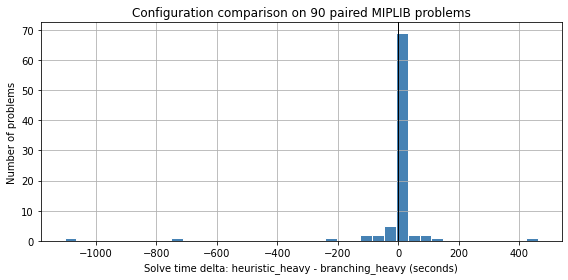

In [172]:
miplib = df_raw[df_raw['config_name'].isin(['branching_heavy', 'heuristic_heavy'])].copy()
piv = miplib.pivot_table(
    index='problem_name',
    columns='config_name',
    values=['metric_timeline_total_seconds', 'metric_num_nodes_total',
            'derived_is_optimal', 'derived_timed_out'],
    aggfunc='first',
)

# Solve-time delta = heuristic_heavy - branching_heavy  (positive => branching_heavy is faster)
delta = (piv[('metric_timeline_total_seconds', 'heuristic_heavy')]
         - piv[('metric_timeline_total_seconds', 'branching_heavy')])
delta = delta.dropna()

print(f'Paired problems: {len(delta)}')
print(f'branching_heavy faster on {(delta > 0).sum()} problems  '
      f'({(delta > 0).mean():.1%})')
print(f'heuristic_heavy faster on    {(delta < 0).sum()} problems  '
      f'({(delta < 0).mean():.1%})')
print(f'Equal time on               {(delta == 0).sum()} problems')
print(f'\nMedian time delta (heuristic_heavy - branching_heavy): {delta.median():+.2f} s')
print(f'Mean   time delta (heuristic_heavy - branching_heavy): {delta.mean():+.2f} s')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(delta.clip(-1500, 1500), bins=40, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Solve time delta: heuristic_heavy - branching_heavy (seconds)')
ax.set_ylabel('Number of problems')
ax.set_title('Configuration comparison on 90 paired MIPLIB problems')
plt.tight_layout()
plt.show()


## 11. H3 Recommendation Experiment

This section directly tests H3 (recommendations correlate with measurable
performance shifts) using the 87 MIPLIB problems for which both solver
configurations reported solve times.

**Ground truth.** For each problem, the configuration with the lower
`metric_timeline_total_seconds` is the one a correct recommendation should
have selected.

**Predictors compared.** Four config-picker strategies are evaluated against
the ground truth:

1. **Random** -- alternating predictions; ~50% expected accuracy.
2. **Majority** -- always predict `heuristic_heavy` (the more often faster
   configuration); 60.9% accuracy by construction.
3. **Rule-based** -- predict `heuristic_heavy` if any of `weak_root_lp`,
   `excessive_branching`, or `ineffective_cuts` fires on the input log
   (these bottlenecks are addressable by more aggressive heuristics);
   otherwise predict `branching_heavy`.
4. **LLM-based** -- ask `Llama-3.2-1B-Instruct` to choose between the two
   configurations given a structural problem summary plus the detected
   bottleneck labels. The summary is constructed without revealing the
   actual solve time of the input log, so the model has to reason from
   problem dimensions, bottleneck pattern, and bound trajectory rather
   than from runtime directly.

For each problem the predictors operate on the `branching_heavy` log; the
question they answer is "given this run, would `heuristic_heavy` have been
faster?" A paired Wilcoxon test confirms that the configurations differ
significantly in solve time before any picker is evaluated.


In [173]:
# Build the paired comparison frame: for each problem with solve times in both
# configurations, record the actual solve times, which config was faster, and
# the heuristic labels detected on each config's log.
paired_problems = []
for problem in df_raw['problem_name'].unique():
    sub = df_raw[df_raw['problem_name'] == problem]
    bh_rows = sub[sub['config_name'] == 'branching_heavy']
    hh_rows = sub[sub['config_name'] == 'heuristic_heavy']
    if len(bh_rows) != 1 or len(hh_rows) != 1:
        continue
    bh_row = bh_rows.iloc[0]
    hh_row = hh_rows.iloc[0]
    bh_time = bh_row['metric_timeline_total_seconds']
    hh_time = hh_row['metric_timeline_total_seconds']
    if pd.isna(bh_time) or pd.isna(hh_time):
        continue

    bh_log = next((p for p in parsed_logs if p.run_id == bh_row['run_id']), None)
    hh_log = next((p for p in parsed_logs if p.run_id == hh_row['run_id']), None)
    if bh_log is None or hh_log is None:
        continue

    bh_labels = [BOTTLENECK_LABELS[i] for i, v in enumerate(label_log(bh_log)) if v]
    hh_labels = [BOTTLENECK_LABELS[i] for i, v in enumerate(label_log(hh_log)) if v]

    if bh_time < hh_time:
        faster = 'branching_heavy'
    elif hh_time < bh_time:
        faster = 'heuristic_heavy'
    else:
        faster = 'tie'

    paired_problems.append({
        'problem': problem,
        'bh_time': bh_time,
        'hh_time': hh_time,
        'faster': faster,
        'delta': hh_time - bh_time,    # positive means BH faster
        'bh_labels': bh_labels,
        'hh_labels': hh_labels,
        'bh_log': bh_log,
        'hh_log': hh_log,
    })

paired_df = pd.DataFrame(paired_problems)
print(f'Paired problems: {len(paired_df)}')
print(f'\nGround truth (which config was faster):')
print(paired_df['faster'].value_counts().to_string())
print(f'\nMean solve-time delta (heuristic_heavy minus branching_heavy): {paired_df["delta"].mean():+.1f}s')
print(f'Median solve-time delta: {paired_df["delta"].median():+.2f}s')


Paired problems: 87

Ground truth (which config was faster):
faster
heuristic_heavy    53
branching_heavy    34

Mean solve-time delta (heuristic_heavy minus branching_heavy): -17.4s
Median solve-time delta: -0.04s


In [174]:
# Per-bottleneck config preference: for each label fired on the branching_heavy
# log, what fraction of those problems were faster under each configuration?
print('Per-bottleneck config preference (basis: branching_heavy log labels):')
print(f'{"label":<24s}  {"n":>3s}  {"BH win":>7s}  {"HH win":>7s}  {"HH%":>6s}  {"avg delta(s)":>14s}')
for lab in BOTTLENECK_LABELS + ['<no labels>']:
    if lab == '<no labels>':
        mask = paired_df['bh_labels'].apply(len) == 0
    else:
        mask = paired_df['bh_labels'].apply(lambda ls: lab in ls)
    sub = paired_df[mask]
    if len(sub) == 0:
        continue
    bh_won = (sub['faster'] == 'branching_heavy').sum()
    hh_won = (sub['faster'] == 'heuristic_heavy').sum()
    hh_pct = hh_won / len(sub)
    avg_delta = sub['delta'].mean()
    print(f'  {lab:<22s}  {len(sub):>3d}  {bh_won:>7d}  {hh_won:>7d}  {hh_pct:>5.1%}  {avg_delta:>+13.1f}')


Per-bottleneck config preference (basis: branching_heavy log labels):
label                       n   BH win   HH win     HH%    avg delta(s)
  weak_root_lp             10        4        6  60.0%         -113.2
  excessive_branching      27       13       14  51.9%          -50.0
  ineffective_cuts         22       10       12  54.5%          -13.9
  degeneracy                7        0        7  100.0%          -37.0
  presolve_weakness        19        7       12  63.2%          -10.9
  <no labels>              31       11       20  64.5%           +3.5


In [175]:
# Rule-based picker: a simple decision rule using the bottleneck labels
# detected on the branching_heavy log. Designed so it's easy to vary.
HEURISTIC_HELPING_LABELS = {'weak_root_lp', 'excessive_branching', 'ineffective_cuts'}

def predict_config_rule_based(labels):
    return 'heuristic_heavy' if any(l in HEURISTIC_HELPING_LABELS for l in labels) else 'branching_heavy'


paired_df['rule_pred'] = paired_df['bh_labels'].apply(predict_config_rule_based)
rule_correct = (paired_df['rule_pred'] == paired_df['faster']).sum()
rule_acc = rule_correct / len(paired_df)
majority_acc = (paired_df['faster'] == 'heuristic_heavy').mean()

print(f'Rule-based picker accuracy: {rule_correct}/{len(paired_df)} = {rule_acc:.1%}')
print(f'  vs. random   (50.0%): {rule_acc - 0.5:+.1%}')
print(f'  vs. majority ({majority_acc:.1%}): {rule_acc - majority_acc:+.1%}')

print('\nConfusion matrix (rows=predicted, cols=actual):')
print(pd.crosstab(paired_df['rule_pred'], paired_df['faster']).to_string())


Rule-based picker accuracy: 38/87 = 43.7%
  vs. random   (50.0%): -6.3%
  vs. majority (60.9%): -17.2%

Confusion matrix (rows=predicted, cols=actual):
faster           branching_heavy  heuristic_heavy
rule_pred                                        
branching_heavy               12               27
heuristic_heavy               22               26


In [176]:
# LLM-based picker: ask Llama-3.2-1B-Instruct to choose between the two
# configurations given a non-time-leaking structural summary and the
# heuristic labels.

def render_problem_for_picker(f):
    '''Compact summary for the picker prompt. Includes structural problem
    features and bottleneck-relevant signals but not the actual solve time,
    so the model has to reason from problem characteristics rather than
    runtime.'''
    parts = [f'Problem {f.problem_name} ({f.num_variables:,} variables, {f.num_constraints:,} constraints, {f.num_nonzeros:,} nonzeros)']
    if f.solution_status == 'optimal':
        parts.append('solved to optimality')
    elif f.solution_status == 'no_solution':
        parts.append('found no solution')
    elif f.timed_out:
        gap = f' with {f.final_rel_gap:.1%} gap remaining' if f.final_rel_gap is not None else ''
        parts.append(f'timed out{gap}')
    elif f.solution_status == 'feasible':
        gap = f' (gap {f.final_rel_gap:.1%})' if f.final_rel_gap is not None else ''
        parts.append(f'reached feasible{gap}')
    if f.num_nodes_total > 0:
        parts.append(f'explored {f.num_nodes_total:,} branch-and-bound nodes')
    if f.num_cuts_generated > 0:
        parts.append(f'{f.num_cuts_generated:,} cuts generated')
    if f.first_dual is not None and f.final_dual is not None:
        parts.append(f'dual bound moved {f.first_dual:.4g} to {f.final_dual:.4g}')
    if f.presolve_var_reduction is not None:
        parts.append(f'presolve reduced variables by {f.presolve_var_reduction:.0%}')
    return '. '.join(parts) + '.'


PICKER_SYSTEM = (
    'You are an expert at predicting optimization solver performance. '
    'Given a Mixed-Integer Programming solver run summary and the detected '
    'performance bottlenecks, predict which of two solver configurations '
    'would likely be faster on this problem.\n\n'
    'Configuration A (branching_heavy): a build that performs aggressive '
    'branch-and-bound search and explores more nodes.\n'
    'Configuration B (heuristic_heavy): a build that runs more primal '
    'heuristics and finds incumbent solutions faster.\n\n'
    'Reply with only the single character A or B - no other text.'
)


def llm_pick_config(f):
    summary = render_problem_for_picker(f)
    labels = [BOTTLENECK_LABELS[i] for i, v in enumerate(label_log(f)) if v]
    labels_str = ', '.join(labels) if labels else 'none'
    user_msg = (
        f'SOLVER RUN: {summary}\n\n'
        f'DETECTED BOTTLENECKS: {labels_str}\n\n'
        f'Which configuration would be faster: A or B?'
    )
    messages = [
        {'role': 'system', 'content': PICKER_SYSTEM},
        {'role': 'user', 'content': user_msg},
    ]
    out = LLM_PIPE(messages, max_new_tokens=4, do_sample=False)
    text = out[0]['generated_text'].strip().upper()
    # Find the first occurrence of A or B in the response
    for ch in text:
        if ch == 'A':
            return 'branching_heavy'
        if ch == 'B':
            return 'heuristic_heavy'
    return None


print(f'Generating LLM config predictions for {len(paired_df)} problems...')
print('(this takes a while on CPU; one inference call per problem)\n')
llm_predictions = []
for i, row in paired_df.iterrows():
    pred = llm_pick_config(row['bh_log'])
    llm_predictions.append(pred)
    if (i + 1) % 10 == 0 or (i + 1) == len(paired_df):
        sys.stderr.write(f'\r  {i+1}/{len(paired_df)} done')
        sys.stderr.flush()
print()

paired_df['llm_pred'] = llm_predictions
print(f'\nLLM predictions distribution:')
print(paired_df['llm_pred'].value_counts(dropna=False).to_string())

llm_correct = (paired_df['llm_pred'] == paired_df['faster']).sum()
llm_acc = llm_correct / len(paired_df)
print(f'\nLLM-based picker accuracy: {llm_correct}/{len(paired_df)} = {llm_acc:.1%}')
print(f'  vs. random   (50.0%): {llm_acc - 0.5:+.1%}')
print(f'  vs. majority ({majority_acc:.1%}): {llm_acc - majority_acc:+.1%}')
print(f'  vs. rule     ({rule_acc:.1%}): {llm_acc - rule_acc:+.1%}')

print('\nConfusion matrix (rows=predicted, cols=actual):')
print(pd.crosstab(paired_df['llm_pred'].fillna('<unparsed>'), paired_df['faster']).to_string())


Generating LLM config predictions for 87 problems...
(this takes a while on CPU; one inference call per problem)



  87/87 done



LLM predictions distribution:
llm_pred
branching_heavy    87

LLM-based picker accuracy: 34/87 = 39.1%
  vs. random   (50.0%): -10.9%
  vs. majority (60.9%): -21.8%
  vs. rule     (43.7%): -4.6%

Confusion matrix (rows=predicted, cols=actual):
faster           branching_heavy  heuristic_heavy
llm_pred                                         
branching_heavy               34               53


In [177]:
# Summary: head-to-head accuracy of the four predictors plus a paired
# Wilcoxon test on the solve-time deltas to confirm the configs differ.
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html
from scipy.stats import wilcoxon

ground_truth = paired_df['faster'].tolist()

# Random predictor: deterministic alternation so the result is reproducible.
random_pred = ['heuristic_heavy' if i % 2 == 0 else 'branching_heavy'
               for i in range(len(paired_df))]
majority_pred = ['heuristic_heavy'] * len(paired_df)

# Treat unparsed LLM responses as wrong (charitable: as 'branching_heavy', the minority)
llm_filled = paired_df['llm_pred'].fillna('branching_heavy').tolist()

def acc(pred, truth):
    return sum(p == t for p, t in zip(pred, truth)) / len(truth)

summary = pd.DataFrame({
    'predictor': ['random (alternating)', 'majority (always heuristic_heavy)',
                  'rule-based', 'LLM-based'],
    'accuracy': [acc(random_pred, ground_truth),
                 acc(majority_pred, ground_truth),
                 rule_acc,
                 llm_acc],
    'n_correct': [sum(p == t for p, t in zip(random_pred, ground_truth)),
                  sum(p == t for p, t in zip(majority_pred, ground_truth)),
                  rule_correct,
                  llm_correct],
})
print('H3 picker accuracy comparison (n=87):')
print(summary.to_string(index=False))

# Paired Wilcoxon on the solve-time deltas: is there a real difference between
# the two configurations to begin with?
stat, pval = wilcoxon(paired_df['bh_time'], paired_df['hh_time'])
print(f'\nPaired Wilcoxon (BH vs HH solve times): statistic={stat:.1f}, p={pval:.4f}')
if pval < 0.05:
    print('  --> reject H0; the two configurations have different solve-time distributions')
else:
    print('  --> fail to reject H0; no significant difference between the two configurations')


H3 picker accuracy comparison (n=87):
                        predictor  accuracy  n_correct
             random (alternating)  0.643678         56
majority (always heuristic_heavy)  0.609195         53
                       rule-based  0.436782         38
                        LLM-based  0.390805         34

Paired Wilcoxon (BH vs HH solve times): statistic=1728.0, p=0.4312
  --> fail to reject H0; no significant difference between the two configurations


## 12. Future Work

Several directions remain open beyond what this notebook implements:

1. **Diagnostic-quality rubric** - apply a structured five-criteria
   scoring rubric (factual accuracy, completeness, actionability,
   terminology correctness, conciseness) to the LLM diagnostics, either
   by expert review or via a calibrated LLM-as-judge.
2. **Three-way LLM-approach comparison** - evaluate prompting-only and a
   fine-tuned baseline alongside the RAG pipeline implemented here.
3. **Statistical analysis** - paired Wilcoxon or t-test on the
   configuration comparison and bootstrap confidence intervals on the
   per-label F1 scores.
4. **Cross-solver evaluation** - apply the parser and classifier to logs
   from Gurobi, HiGHS, or CPLEX to characterize how well the diagnostic
   patterns generalize beyond Rose.


## 13. Gold-Label Evaluation

`gold_labels_reviewed.xlsx` contains a 30-run stratified sample of the
dataset that has been hand-reviewed against the underlying metric evidence.
The workbook has three sheets:

- **Instructions** - how the labeling worksheet is organized.
- **Labels** - one row per run with metric evidence, the heuristic-rule
  labels (`h_*`), the pre-label suggestions (`sug_*`), and the final gold
  labels (`gold_*`). Yellow highlighting marks gold cells where the
  reviewer overrode the heuristic.
- **Summary** - live counts of positives and disagreements per label.

The cells below load the workbook and compute (i) how closely the
heuristic rules approximate the gold labels (the supervision noise floor)
and (ii) how the trained classifier performs against the gold subset
relative to the heuristic rules it was trained against.


In [178]:
GOLD_PATH = 'gold_labels_reviewed.xlsx'
gold_raw = pd.read_excel(GOLD_PATH, sheet_name='Labels', header=1)
print(f'Loaded {len(gold_raw)} gold-labeled runs from {GOLD_PATH}')

gold_cols = [f'gold_{l}' for l in BOTTLENECK_LABELS]
h_cols = [f'h_{l}' for l in BOTTLENECK_LABELS]
print(f'\nGold positives per label:')
for l in BOTTLENECK_LABELS:
    n = int(gold_raw[f'gold_{l}'].sum())
    print(f'  {l:22s} : {n}/{len(gold_raw)}')
print(f'\nDisagreements with heuristic per label:')
for l in BOTTLENECK_LABELS:
    n = int((gold_raw[f'gold_{l}'] != gold_raw[f'h_{l}']).sum())
    print(f'  {l:22s} : {n}/{len(gold_raw)}')


Loaded 30 gold-labeled runs from gold_labels_reviewed.xlsx

Gold positives per label:
  weak_root_lp           : 10/30
  excessive_branching    : 11/30
  ineffective_cuts       : 9/30
  degeneracy             : 5/30
  presolve_weakness      : 4/30

Disagreements with heuristic per label:
  weak_root_lp           : 0/30
  excessive_branching    : 0/30
  ineffective_cuts       : 0/30
  degeneracy             : 2/30
  presolve_weakness      : 4/30


In [179]:
# Heuristic-vs-gold: how noisy are the rules used to weakly-supervise the classifier?
y_gold = gold_raw[[f'gold_{l}' for l in BOTTLENECK_LABELS]].values.astype(int)
y_heur = gold_raw[[f'h_{l}' for l in BOTTLENECK_LABELS]].values.astype(int)

rows = []
for i, l in enumerate(BOTTLENECK_LABELS):
    rows.append({
        'label': l,
        'gold_pos': int(y_gold[:, i].sum()),
        'precision': precision_score(y_gold[:, i], y_heur[:, i], zero_division=0),
        'recall':    recall_score(y_gold[:, i], y_heur[:, i], zero_division=0),
        'f1':        f1_score(y_gold[:, i], y_heur[:, i], zero_division=0),
    })
heur_eval = pd.DataFrame(rows).set_index('label')
print('Heuristic rules vs. gold labels (the supervision noise floor):')
print(heur_eval.round(3).to_string())
print(f'\nMacro-F1 (heuristic vs gold): {heur_eval["f1"].mean():.3f}')
print(f'Micro-F1 (heuristic vs gold): '
      f'{f1_score(y_gold, y_heur, average="micro", zero_division=0):.3f}')


Heuristic rules vs. gold labels (the supervision noise floor):
                     gold_pos  precision  recall     f1
label                                                  
weak_root_lp               10      1.000     1.0  1.000
excessive_branching        11      1.000     1.0  1.000
ineffective_cuts            9      1.000     1.0  1.000
degeneracy                  5      0.714     1.0  0.833
presolve_weakness           4      0.500     1.0  0.667

Macro-F1 (heuristic vs gold): 0.900
Micro-F1 (heuristic vs gold): 0.929


In [180]:
# Classifier-vs-gold: does the trained classifier track human judgment
# better than the rules it was trained on?
gold_run_ids = gold_raw['run_id'].tolist()
gold_feature_rows = [
    next(p for p in parsed_logs if p.run_id == rid) for rid in gold_run_ids
]

# Use features_to_array + the same scaler we fit on training data
gold_X = features_to_array(gold_feature_rows)
gold_X_s = scaler.transform(gold_X).astype(np.float32)

model_cls.eval()
with torch.no_grad():
    gold_probs = model_cls(
        torch.tensor(gold_X_s, dtype=torch.float32).to(Device)
    ).cpu().numpy()
gold_preds = (gold_probs >= THRESHOLD).astype(int)

rows = []
for i, l in enumerate(BOTTLENECK_LABELS):
    n_pos = int(y_gold[:, i].sum())
    if n_pos == 0 or n_pos == len(y_gold):
        auc = float('nan')
    else:
        auc = roc_auc_score(y_gold[:, i], gold_probs[:, i])
    rows.append({
        'label': l,
        'gold_pos': n_pos,
        'precision': precision_score(y_gold[:, i], gold_preds[:, i], zero_division=0),
        'recall':    recall_score(y_gold[:, i], gold_preds[:, i], zero_division=0),
        'f1':        f1_score(y_gold[:, i], gold_preds[:, i], zero_division=0),
        'roc_auc':   auc,
    })
cls_eval = pd.DataFrame(rows).set_index('label')
print('PyTorch classifier vs. gold labels:')
print(cls_eval.round(3).to_string())
print(f'\nMacro-F1 (classifier vs gold): {cls_eval["f1"].mean():.3f}')
print(f'Micro-F1 (classifier vs gold): '
      f'{f1_score(y_gold, gold_preds, average="micro", zero_division=0):.3f}')

# Side-by-side: heuristic noise floor vs model
cmp = pd.DataFrame({
    'gold_pos': cls_eval['gold_pos'],
    'heur_f1': heur_eval['f1'],
    'model_f1': cls_eval['f1'],
    'delta':    cls_eval['f1'] - heur_eval['f1'],
})
print('\nHeuristic vs. classifier F1 on gold:')
print(cmp.round(3).to_string())


PyTorch classifier vs. gold labels:
                     gold_pos  precision  recall     f1  roc_auc
label                                                           
weak_root_lp               10      1.000   1.000  1.000    1.000
excessive_branching        11      0.909   0.909  0.909    0.990
ineffective_cuts            9      1.000   0.889  0.941    0.995
degeneracy                  5      1.000   1.000  1.000    1.000
presolve_weakness           4      0.500   1.000  0.667    0.846

Macro-F1 (classifier vs gold): 0.903
Micro-F1 (classifier vs gold): 0.914

Heuristic vs. classifier F1 on gold:
                     gold_pos  heur_f1  model_f1  delta
label                                                  
weak_root_lp               10    1.000     1.000  0.000
excessive_branching        11    1.000     0.909 -0.091
ineffective_cuts            9    1.000     0.941 -0.059
degeneracy                  5    0.833     1.000  0.167
presolve_weakness           4    0.667     0.667  0.000


In [181]:
# Per-run audit: where do model and heuristic agree / disagree with gold?
audit = pd.DataFrame({'run_id': gold_run_ids})
for i, l in enumerate(BOTTLENECK_LABELS):
    audit[f'gold_{l}'] = y_gold[:, i]
    audit[f'h_{l}']    = y_heur[:, i]
    audit[f'm_{l}']    = gold_preds[:, i]
# Counts of correct labels per run
audit['gold_n_labels'] = y_gold.sum(axis=1)
audit['h_correct']     = (y_heur == y_gold).sum(axis=1)
audit['m_correct']     = (gold_preds == y_gold).sum(axis=1)
print('Per-run accuracy audit (out of 5 labels):')
print(audit[['run_id', 'gold_n_labels', 'h_correct', 'm_correct']].to_string(index=False))


Per-run accuracy audit (out of 5 labels):
                                      run_id  gold_n_labels  h_correct  m_correct
                     branching_heavy::50v-10              3          5          5
                     branching_heavy::cheese              0          5          5
                    branching_heavy::dano3_5              2          5          5
                branching_heavy::f2gap801600              3          5          4
                  branching_heavy::gen-ip002              1          4          4
                  branching_heavy::gen-ip054              1          3          4
branching_heavy::gfd-schedulen180f7d50m30k18              1          5          5
                      branching_heavy::map10              0          5          5
              branching_heavy::markshare_4_0              2          4          4
        branching_heavy::neos-5052403-cygnet              1          5          5
                branching_heavy::neos-860300            

## 14. Diagnostic-Quality Rubric

`diagnostic_rubric.xlsx` contains hand-scored evaluations of the three
worked-example diagnostics from Section 9. Each diagnostic is rated on
five 1-5 Likert criteria (factual accuracy, completeness, actionability,
terminology correctness, conciseness) following anchors documented in
the workbook's Instructions sheet. The cell below loads the workbook
and reports per-diagnostic totals plus per-criterion means; the same
numbers are cited in Section 6.5 of the paper.


Per-diagnostic scores (max 25 per diagnostic):
diagnostic                           factual_  complete  actionab  terminol  concisen  total   mean
  unitcal_7                                 4         5         4         5         3     21   4.20
  gfd-schedulen180f7d50m30k18               2         5         3         4         4     18   3.60
  air05 (healthy)                           1         3         1         2         3     10   2.00

Per-criterion means (n=3 diagnostics):
  factual_accuracy        2.33
  completeness            4.33
  actionability           2.67
  terminology             3.67
  conciseness             3.33

Overall mean (15 scores): 3.27


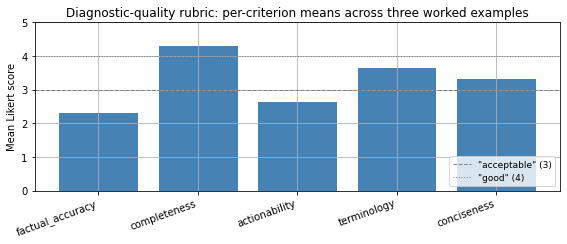

In [182]:
RUBRIC_PATH = 'diagnostic_rubric.xlsx'
rubric = pd.read_excel(RUBRIC_PATH, sheet_name='Scoring', header=1)

CRITERIA = ['factual_accuracy', 'completeness', 'actionability',
            'terminology', 'conciseness']

# Per-diagnostic totals
print('Per-diagnostic scores (max 25 per diagnostic):')
print(f'{"diagnostic":<35s}  ' + '  '.join(f'{c[:8]:>8s}' for c in CRITERIA) + '  total   mean')
for _, row in rubric.iterrows():
    scores = [int(row[c]) for c in CRITERIA]
    total = sum(scores)
    print(f'  {str(row["diagnostic_id"]):<33s}  ' +
          '  '.join(f'{s:>8d}' for s in scores) +
          f'  {total:>5d}  {total/5:>5.2f}')

# Per-criterion means
print('\nPer-criterion means (n=3 diagnostics):')
for c in CRITERIA:
    m = rubric[c].mean()
    print(f'  {c:<22s}  {m:.2f}')

# Overall mean
all_scores = rubric[CRITERIA].values.flatten()
print(f'\nOverall mean (15 scores): {all_scores.mean():.2f}')

# Bar chart: per-criterion mean
fig, ax = plt.subplots(figsize=(8, 3.5))
means = [rubric[c].mean() for c in CRITERIA]
bars = ax.bar(CRITERIA, means, color='steelblue', edgecolor='white')
ax.axhline(3, color='gray', linestyle='--', linewidth=1, label='"acceptable" (3)')
ax.axhline(4, color='gray', linestyle=':',  linewidth=1, label='"good" (4)')
ax.set_ylim(0, 5)
ax.set_ylabel('Mean Likert score')
ax.set_title('Diagnostic-quality rubric: per-criterion means across three worked examples')
ax.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
